In [1]:
#=====CELL 1: IMPORTS & SETUP======
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx # specific library for adding basemaps

# Set a professional plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("flare")

# Define the path to your processed data
DATA_PATH = '../data/processed/hazards_by_location_washington.geojson'

print("Visualization libraries loaded successfully.")

Visualization libraries loaded successfully.


In [2]:
#=====CELL 2: LOAD DATA======
# Load the processed GeoJSON
df_hazards = gpd.read_file(DATA_PATH)

# Enforce logical ordering for the 'danger_level' category
# This ensures "Low" appears on the left and "Extreme" on the right in charts
danger_order = ['Low', 'Moderate', 'High', 'Very High', 'Extreme']
df_hazards['danger_level'] = pd.Categorical(
    df_hazards['danger_level'], 
    categories=danger_order, 
    ordered=True
)

print(f"Data loaded: {len(df_hazards)} records.")
df_hazards.head(3)

Data loaded: 8520 records.


,fire_count,fire_avg_acres,earthquake_count,earthquake_max_mag,flood_zone,flood_danger,danger_score,danger_level,geometry
0,0,0.0,0,0.0,None,None,0,Low,POINT (-114.1 37)
1,0,0.0,0,0.0,None,None,0,Low,POINT (-114.09 37)
2,0,0.0,0,0.0,None,None,0,Low,POINT (-114.08 37)


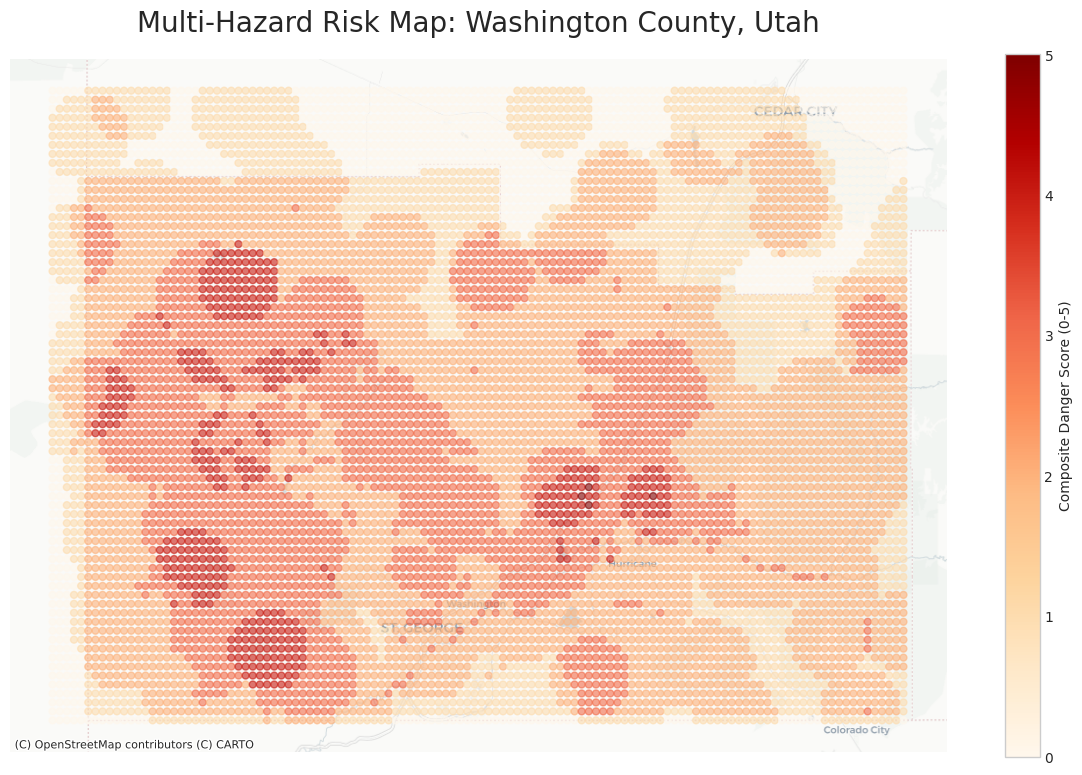

In [8]:
#=====CELL 3: GEOSPATIAL VISUALIZATION (MAP)======

# 1. Reproject to Web Mercator (EPSG:3857) 
# This is required to align correctly with the contextily basemap
df_web_mercator = df_hazards.to_crs(epsg=3857)

# 2. Setup the Plot
fig, ax = plt.subplots(figsize=(12, 12))

# 3. Plot the data
df_web_mercator.plot(
    column='danger_score',
    ax=ax,
    cmap='OrRd',       # Orange to Red colormap
    markersize=25,     # Adjust size based on how "dense" your grid looks
    alpha=0.6,         # Transparency helps see the map underneath
    legend=True,
    legend_kwds={'label': "Composite Danger Score (0-5)", 'shrink': 0.6}
)

# 4. Add Basemap (OpenStreetMap style)
try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
except Exception as e:
    print("Could not load basemap. Check internet connection.")

# 5. Styling
ax.set_title('Multi-Hazard Risk Map: Washington County, Utah', fontsize=20, pad=20)
ax.set_axis_off() # Remove lat/lon axis numbers for a cleaner look

plt.tight_layout()
plt.show()

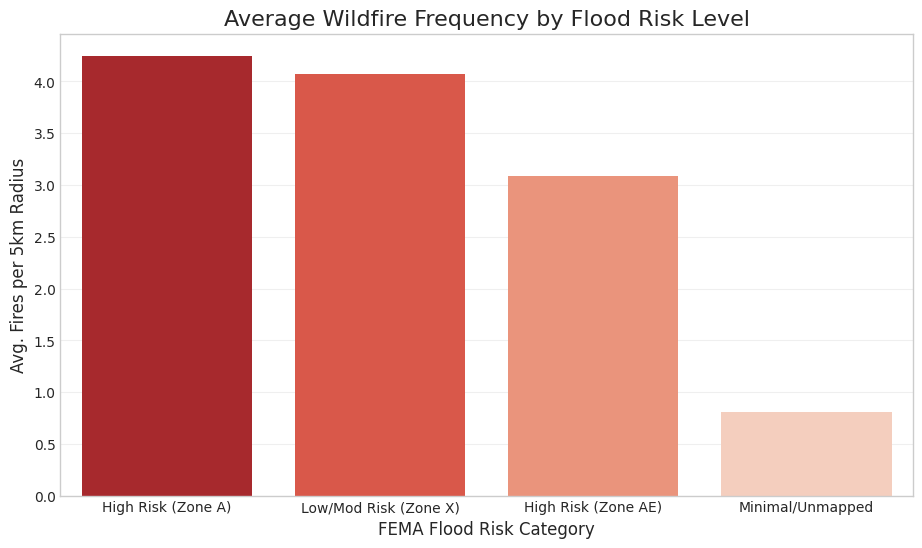

In [ ]:
#=====CELL 4: STATISTICAL CHART (BAR PLOT) - READABLE LABELS======

# 1. Create a Mapping Dictionary
# This translates the technical codes into plain English
label_mapping = {
    'A': 'High Risk (Zone A)',
    'AE': 'High Risk (Zone B)',
    'X': 'Low/Mod Risk (Zone C)',
    'None': 'Minimal/Unmapped'
}

# 2. Apply the mapping to create a readable column
# We use .map() to swap the codes for the descriptions
df_hazards['flood_desc'] = df_hazards['flood_zone'].map(label_mapping).fillna(df_hazards['flood_zone'])

# 3. Aggregate Data using the NEW descriptions
zone_stats = df_hazards.groupby('flood_desc')['fire_count'].mean().reset_index()
# Sort by fire count so the highest bar is first
zone_stats = zone_stats.sort_values(by='fire_count', ascending=False)

# 4. Setup Plot
plt.figure(figsize=(11, 6))

# 5. Create Bar Chart
sns.barplot(
    data=zone_stats, 
    x='flood_desc', 
    y='fire_count', 
    palette='Reds_r',
    hue='flood_desc' 
)

# 6. Styling
plt.title('Average Wildfire Frequency by Flood Risk Level', fontsize=16)
plt.xlabel('FEMA Flood Risk Rating', fontsize=12)
plt.ylabel('Avg. Fires per 5km Radius', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

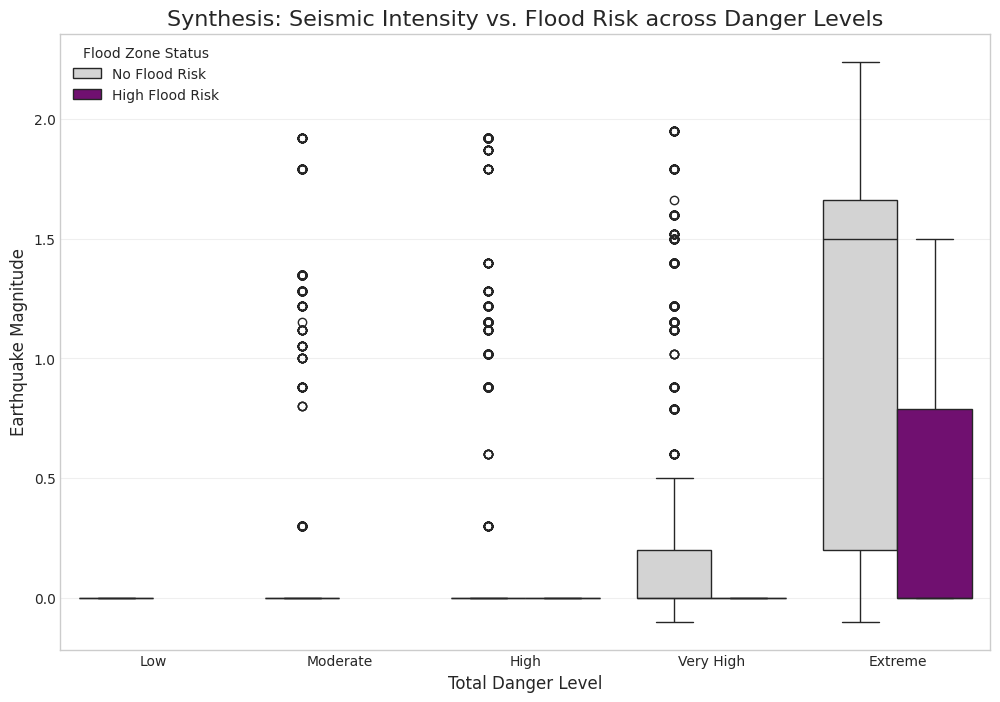

In [11]:
#=====CELL 5: SYNTHESIS VISUALIZATION (BOX PLOT - EARTHQUAKE FOCUS)======

# 1. Prepare Data for Synthesis
# Create a simplified binary column for flood risk
df_hazards['is_flood_risk'] = df_hazards['flood_zone'].apply(
    lambda x: 'No Flood Risk' if x in ['X', 'None'] else 'High Flood Risk'
)

# 2. Setup Plot
plt.figure(figsize=(12, 8))

# 3. Create Box Plot
# Y-axis is now Earthquake Magnitude instead of Fire Count
sns.boxplot(
    data=df_hazards,
    x='danger_level',
    y='earthquake_max_mag', # <--- CHANGED HERE
    hue='is_flood_risk',
    palette={'No Flood Risk': 'lightgrey', 'High Flood Risk': 'purple'}, # Purple usually signifies seismic/structural risk
    showfliers=True # specific for earthquakes: we WANT to see the outliers (rare strong quakes)
)

# 4. Styling
plt.title('Synthesis: Seismic Intensity vs. Flood Risk across Danger Levels', fontsize=16)
plt.xlabel('Total Danger Level', fontsize=12)
plt.ylabel('Earthquake Magnitude', fontsize=12)
plt.legend(title='Flood Zone Status', loc='upper left')

# Add a grid to make it easier to read the small magnitude numbers
plt.grid(axis='y', alpha=0.3) 

plt.show()